# EE 446 Homework 1 Programming Notebook

Use the **tinyml-arduino** Python environment that you set up for this class. In JupyterLab, select the kernel named **Python (tinyml-arduino)** before running this notebook.

Do not install or uninstall TensorFlow packages inside this notebook. The class environment already contains the required packages for this assignment, including TensorFlow, TensorFlow Model Optimization Toolkit, scikit-learn, NumPy, pandas, and JupyterLab.

This notebook contains the programming questions marked **[Pro]**. Complete each section by replacing the placeholder comments with your own code. Print the requested outputs so that your work can be graded directly from the notebook.


In [1]:
import sys
print(sys.executable)

/home/Brayden/ai/projects/tinyml-arduino/bin/python


In [2]:
import sys
!{sys.executable} -m pip install "tensorflow-model-optimization==0.8.0"


[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: pip install --upgrade pip


In [3]:
import sys
!{sys.executable} -m pip install "keras==2.14.0"


[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: pip install --upgrade pip


In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.metrics import classification_report, confusion_matrix, r2_score

import tensorflow as tf
import tensorflow_model_optimization as tfmot

Sequential = tf.keras.Sequential
Dense = tf.keras.layers.Dense
LSTM = tf.keras.layers.LSTM
to_categorical = tf.keras.utils.to_categorical

print("TensorFlow version:", tf.__version__)
print("TF-MOT version:", tfmot.__version__)

2026-05-19 14:15:25.409050: I tensorflow/core/util/port.cc:111] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-05-19 14:15:25.411476: I tensorflow/tsl/cuda/cudart_stub.cc:28] Could not find cuda drivers on your machine, GPU will not be used.
2026-05-19 14:15:25.446546: E tensorflow/compiler/xla/stream_executor/cuda/cuda_dnn.cc:9342] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-05-19 14:15:25.446595: E tensorflow/compiler/xla/stream_executor/cuda/cuda_fft.cc:609] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-05-19 14:15:25.446620: E tensorflow/compiler/xla/stream_executor/cuda/cuda_blas.cc:1518] Unable to register cuBLAS factory: Attempting to regi

TensorFlow version: 2.14.1
TF-MOT version: 0.8.0



---

# Problem 1: DNN and Wine Classification (80 points)

This problem uses the Wine dataset available through scikit-learn. The dataset is loaded locally from the installed package, so no external data file is required.


In [5]:
# Load the Wine dataset from scikit-learn.
# This avoids requiring an external wine.data file.

wine = load_wine(as_frame=True)

feature_names = list(wine.feature_names)
df = wine.frame.copy()
df["Class"] = wine.target

# Reorder the columns so that the class label appears first.
df = df[["Class"] + feature_names]

# Number of classes
num_classes = df["Class"].nunique()
print("Number of classes:", num_classes)

# Number of features, excluding the class label
num_features = df.shape[1] - 1
print("Number of features:", num_features)

# Basic feature statistics
feature_stats = df.drop(columns=["Class"]).describe().T[["min", "max", "mean", "std"]]
print("\nFeature statistics:\n", feature_stats)

# Class distribution
class_counts = df["Class"].value_counts().sort_index()
print("\nClass distribution:\n", class_counts)


Number of classes: 3
Number of features: 13

Feature statistics:
                                  min      max        mean         std
alcohol                        11.03    14.83   13.000618    0.811827
malic_acid                      0.74     5.80    2.336348    1.117146
ash                             1.36     3.23    2.366517    0.274344
alcalinity_of_ash              10.60    30.00   19.494944    3.339564
magnesium                      70.00   162.00   99.741573   14.282484
total_phenols                   0.98     3.88    2.295112    0.625851
flavanoids                      0.34     5.08    2.029270    0.998859
nonflavanoid_phenols            0.13     0.66    0.361854    0.124453
proanthocyanins                 0.41     3.58    1.590899    0.572359
color_intensity                 1.28    13.00    5.058090    2.318286
hue                             0.48     1.71    0.957449    0.228572
od280/od315_of_diluted_wines    1.27     4.00    2.611685    0.709990
proline                 

## Problem 1 - Part (a)
### Base Model Training and Evaluation


In [6]:
# Step 1: Separate the feature matrix and class labels.
X = wine.data
y = wine.target


In [7]:
# Step 2: Perform a train-test split (70% train, 30% test) using random_state=42

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [8]:
# Step 3: Use StandardScaler to normalize the features
# - Fit on X_train and transform both X_train and X_test

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [9]:
# Step 4: Use one-hot encoding for y_train and y_test.
# - Use tf.keras.utils.to_categorical.
# - Use num_classes=num_classes to make the output shape explicit.

num_classes = 3

y_train = tf.keras.utils.to_categorical(y_train, num_classes=num_classes)
y_test = tf.keras.utils.to_categorical(y_test, num_classes=num_classes)


In [10]:
# Step 5: Define a Sequential model with the following architecture:
# - Dense(64, activation='relu')
# - Dense(32, activation='relu')
# - Dense(num_classes, activation='softmax')
# Make sure the first Dense layer receives the correct input shape.

# <-- Enter your code here <--#

model = Sequential([
    Dense(64, activation='relu', input_shape=(X_train.shape[1],)),
    Dense(32, activation='relu'),
    Dense(num_classes, activation='softmax')
])


2026-05-19 14:15:27.861030: E tensorflow/compiler/xla/stream_executor/cuda/cuda_driver.cc:268] failed call to cuInit: CUDA_ERROR_NO_DEVICE: no CUDA-capable device is detected


In [11]:
# Step 6: Compile using Adam optimizer, categorical_crossentropy loss, and accuracy metric

model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

history = model.fit(X_train, y_train,
                    epochs=20,
                    batch_size=8,
                    validation_split=0.2)


Epoch 1/20
13/13 [==============================] - 1s 18ms/step - loss: 1.0526 - accuracy: 0.3838 - val_loss: 0.8366 - val_accuracy: 0.6800
Epoch 2/20
13/13 [==============================] - 0s 4ms/step - loss: 0.7672 - accuracy: 0.8990 - val_loss: 0.6236 - val_accuracy: 0.9600
Epoch 3/20
13/13 [==============================] - 0s 4ms/step - loss: 0.5603 - accuracy: 0.9394 - val_loss: 0.4561 - val_accuracy: 1.0000
Epoch 4/20
13/13 [==============================] - 0s 4ms/step - loss: 0.4039 - accuracy: 0.9697 - val_loss: 0.3241 - val_accuracy: 1.0000
Epoch 5/20
13/13 [==============================] - 0s 4ms/step - loss: 0.2908 - accuracy: 0.9697 - val_loss: 0.2324 - val_accuracy: 1.0000
Epoch 6/20
13/13 [==============================] - 0s 4ms/step - loss: 0.2142 - accuracy: 0.9798 - val_loss: 0.1706 - val_accuracy: 1.0000
Epoch 7/20
13/13 [==============================] - 0s 4ms/step - loss: 0.1634 - accuracy: 0.9798 - val_loss: 0.1294 - val_accuracy: 1.0000
Epoch 8/20
13/13 [=

Test Accuracy: 1.0000
2/2 [==============================] - 0s 4ms/step

Classification Report:
              precision    recall  f1-score   support

     class_0       1.00      1.00      1.00        19
     class_1       1.00      1.00      1.00        21
     class_2       1.00      1.00      1.00        14

    accuracy                           1.00        54
   macro avg       1.00      1.00      1.00        54
weighted avg       1.00      1.00      1.00        54



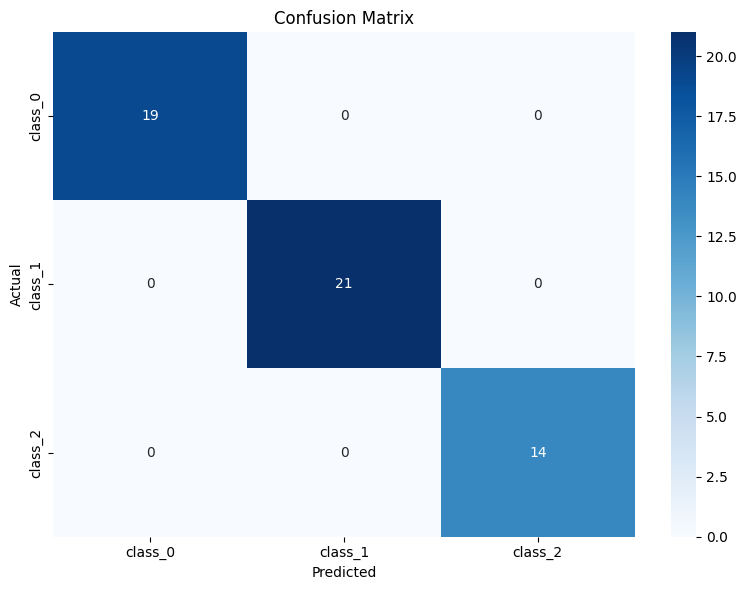

In [12]:
# Step 7: Evaluate the model on test data and print:
# - Accuracy
# - Classification report
# - Confusion matrix

test_loss, test_accuracy = model.evaluate(X_test, y_test, verbose=0)
print(f"Test Accuracy: {test_accuracy:.4f}")

y_pred = np.argmax(model.predict(X_test), axis=1)
y_true = np.argmax(y_test, axis=1)

print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=wine.target_names))

import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=wine.target_names,
            yticklabels=wine.target_names)
plt.title('Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()


In [13]:
import os
# Step 8: Convert the trained model to TFLite format
converter = tf.lite.TFLiteConverter.from_keras_model(model)
tflite_model = converter.convert()

tflite_path = "model_base.tflite"
with open(tflite_path, 'wb') as f:
    f.write(tflite_model)

# Print the file size in kilobytes
file_size_kb = os.path.getsize(tflite_path) / 1024
print(f"TFLite model saved as '{tflite_path}'")
print(f"File size: {file_size_kb:.2f} KB")


INFO:tensorflow:Assets written to: /tmp/tmpkcuihry0/assets


INFO:tensorflow:Assets written to: /tmp/tmpkcuihry0/assets


TFLite model saved as 'model_base.tflite'
File size: 14.07 KB


2026-05-19 14:15:31.161650: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:378] Ignored output_format.
2026-05-19 14:15:31.161683: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:381] Ignored drop_control_dependency.
2026-05-19 14:15:31.162033: I tensorflow/cc/saved_model/reader.cc:83] Reading SavedModel from: /tmp/tmpkcuihry0
2026-05-19 14:15:31.162945: I tensorflow/cc/saved_model/reader.cc:51] Reading meta graph with tags { serve }
2026-05-19 14:15:31.162962: I tensorflow/cc/saved_model/reader.cc:146] Reading SavedModel debug info (if present) from: /tmp/tmpkcuihry0
2026-05-19 14:15:31.165583: I tensorflow/compiler/mlir/mlir_graph_optimization_pass.cc:382] MLIR V1 optimization pass is not enabled
2026-05-19 14:15:31.166320: I tensorflow/cc/saved_model/loader.cc:233] Restoring SavedModel bundle.
2026-05-19 14:15:31.208291: I tensorflow/cc/saved_model/loader.cc:217] Running initialization op on SavedModel bundle at path: /tmp/tmpkcuihry0
2026-05

## Problem 1 - Part (b)

### Quantization (int8, float16, dynamic range)


In [14]:
def file_size_kb(filename):
    """Return the file size in kilobytes."""
    return os.path.getsize(filename) / 1024

def representative_data_gen(X_reference, num_samples=100):
    """Create a representative dataset generator for full integer quantization."""
    max_samples = min(num_samples, len(X_reference))
    for i in range(max_samples):
        yield [X_reference[i:i + 1].astype(np.float32)]

def quantize_and_evaluate(model, X_test, y_test_cat, quant_type, filename):
    """Convert a Keras model to TFLite, evaluate it, and report model size."""

    # Create the TFLite converter from the trained Keras model
    converter = tf.lite.TFLiteConverter.from_keras_model(model)

    # Step 1: Apply quantization settings
    if quant_type == 'int8':
        # (a) Enable default optimizations
        converter.optimizations = [tf.lite.Optimize.DEFAULT]
        # (b) Provide representative dataset
        converter.representative_dataset = lambda: representative_data_gen(X_train)
        # (c) Set supported ops to INT8
        converter.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS_INT8]
        # (d) Set input and output types to int8
        converter.inference_input_type = tf.int8
        converter.inference_output_type = tf.int8

    elif quant_type == 'float16':
        # (a) Enable default optimizations
        converter.optimizations = [tf.lite.Optimize.DEFAULT]
        # (b) Set supported types to float16
        converter.target_spec.supported_types = [tf.float16]

    elif quant_type == 'dynamic':
        # (a) Enable default optimizations only
        converter.optimizations = [tf.lite.Optimize.DEFAULT]

    else:
        raise ValueError("quant_type must be one of: 'int8', 'float16', or 'dynamic'.")

    # Step 2: Convert and save the model
    tflite_model = converter.convert()
    with open(filename, 'wb') as f:
        f.write(tflite_model)

    # Step 3: Run TFLite inference
    interpreter = tf.lite.Interpreter(model_path=filename)
    interpreter.allocate_tensors()

    input_details  = interpreter.get_input_details()[0]
    output_details = interpreter.get_output_details()[0]

    y_true = np.argmax(y_test_cat, axis=1)
    y_pred = []

    for i in range(len(X_test)):
        sample = X_test[i:i + 1].astype(np.float32)

        # Quantize input if model expects int8
        if input_details['dtype'] == np.int8:
            scale, zero_point = input_details['quantization']
            sample = (sample / scale + zero_point).astype(np.int8)

        interpreter.set_tensor(input_details['index'], sample)
        interpreter.invoke()
        output = interpreter.get_tensor(output_details['index'])

        # Dequantize output if model outputs int8
        if output_details['dtype'] == np.int8:
            scale, zero_point = output_details['quantization']
            output = (output.astype(np.float32) - zero_point) * scale

        y_pred.append(np.argmax(output))

    y_pred = np.array(y_pred)

    # Step 4: Report results
    print(f"\n{quant_type.upper()} TFLite model size: {file_size_kb(filename):.2f} KB")
    print(f"\nClassification Report ({quant_type.upper()}):")
    print(classification_report(y_true, y_pred, target_names=wine.target_names))
    print(f"Confusion Matrix ({quant_type.upper()}):")
    print(confusion_matrix(y_true, y_pred))

In [15]:
# Step 5: Use the function above to create and evaluate three quantized models:

quantize_and_evaluate(model, X_test, y_test, 'int8',    'model_int8.tflite')
quantize_and_evaluate(model, X_test, y_test, 'float16', 'model_float16.tflite')
quantize_and_evaluate(model, X_test, y_test, 'dynamic', 'model_dynamic.tflite')


INFO:tensorflow:Assets written to: /tmp/tmpeo92bv2o/assets


INFO:tensorflow:Assets written to: /tmp/tmpeo92bv2o/assets
/home/Brayden/ai/projects/tinyml-arduino/lib/python3.11/site-packages/tensorflow/lite/python/convert.py:947: UserWarning: Statistics for quantized inputs were expected, but not specified; continuing anyway.
  warnings.warn(
2026-05-19 14:15:32.111619: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:378] Ignored output_format.
2026-05-19 14:15:32.111649: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:381] Ignored drop_control_dependency.
2026-05-19 14:15:32.111844: I tensorflow/cc/saved_model/reader.cc:83] Reading SavedModel from: /tmp/tmpeo92bv2o
2026-05-19 14:15:32.112894: I tensorflow/cc/saved_model/reader.cc:51] Reading meta graph with tags { serve }
2026-05-19 14:15:32.112914: I tensorflow/cc/saved_model/reader.cc:146] Reading SavedModel debug info (if present) from: /tmp/tmpeo92bv2o
2026-05-19 14:15:32.115592: I tensorflow/cc/saved_model/loader.cc:233] Restoring SavedModel bundle.
2


INT8 TFLite model size: 5.74 KB

Classification Report (INT8):
              precision    recall  f1-score   support

     class_0       1.00      1.00      1.00        19
     class_1       1.00      1.00      1.00        21
     class_2       1.00      1.00      1.00        14

    accuracy                           1.00        54
   macro avg       1.00      1.00      1.00        54
weighted avg       1.00      1.00      1.00        54

Confusion Matrix (INT8):
[[19  0  0]
 [ 0 21  0]
 [ 0  0 14]]
INFO:tensorflow:Assets written to: /tmp/tmpqq76zu2a/assets


INFO:tensorflow:Assets written to: /tmp/tmpqq76zu2a/assets
2026-05-19 14:15:32.726980: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:378] Ignored output_format.
2026-05-19 14:15:32.727016: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:381] Ignored drop_control_dependency.
2026-05-19 14:15:32.727218: I tensorflow/cc/saved_model/reader.cc:83] Reading SavedModel from: /tmp/tmpqq76zu2a
2026-05-19 14:15:32.727926: I tensorflow/cc/saved_model/reader.cc:51] Reading meta graph with tags { serve }
2026-05-19 14:15:32.727935: I tensorflow/cc/saved_model/reader.cc:146] Reading SavedModel debug info (if present) from: /tmp/tmpqq76zu2a
2026-05-19 14:15:32.729973: I tensorflow/cc/saved_model/loader.cc:233] Restoring SavedModel bundle.
2026-05-19 14:15:32.764791: I tensorflow/cc/saved_model/loader.cc:217] Running initialization op on SavedModel bundle at path: /tmp/tmpqq76zu2a
2026-05-19 14:15:32.774534: I tensorflow/cc/saved_model/loader.cc:316] SavedModel


FLOAT16 TFLite model size: 8.95 KB

Classification Report (FLOAT16):
              precision    recall  f1-score   support

     class_0       1.00      1.00      1.00        19
     class_1       1.00      1.00      1.00        21
     class_2       1.00      1.00      1.00        14

    accuracy                           1.00        54
   macro avg       1.00      1.00      1.00        54
weighted avg       1.00      1.00      1.00        54

Confusion Matrix (FLOAT16):
[[19  0  0]
 [ 0 21  0]
 [ 0  0 14]]
INFO:tensorflow:Assets written to: /tmp/tmpgqcg6myn/assets


INFO:tensorflow:Assets written to: /tmp/tmpgqcg6myn/assets
2026-05-19 14:15:33.318280: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:378] Ignored output_format.
2026-05-19 14:15:33.318317: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:381] Ignored drop_control_dependency.



DYNAMIC TFLite model size: 8.17 KB

Classification Report (DYNAMIC):
              precision    recall  f1-score   support

     class_0       1.00      1.00      1.00        19
     class_1       1.00      1.00      1.00        21
     class_2       1.00      1.00      1.00        14

    accuracy                           1.00        54
   macro avg       1.00      1.00      1.00        54
weighted avg       1.00      1.00      1.00        54

Confusion Matrix (DYNAMIC):
[[19  0  0]
 [ 0 21  0]
 [ 0  0 14]]


2026-05-19 14:15:33.318539: I tensorflow/cc/saved_model/reader.cc:83] Reading SavedModel from: /tmp/tmpgqcg6myn
2026-05-19 14:15:33.319505: I tensorflow/cc/saved_model/reader.cc:51] Reading meta graph with tags { serve }
2026-05-19 14:15:33.319516: I tensorflow/cc/saved_model/reader.cc:146] Reading SavedModel debug info (if present) from: /tmp/tmpgqcg6myn
2026-05-19 14:15:33.322091: I tensorflow/cc/saved_model/loader.cc:233] Restoring SavedModel bundle.
2026-05-19 14:15:33.358015: I tensorflow/cc/saved_model/loader.cc:217] Running initialization op on SavedModel bundle at path: /tmp/tmpgqcg6myn
2026-05-19 14:15:33.368132: I tensorflow/cc/saved_model/loader.cc:316] SavedModel load for tags { serve }; Status: success: OK. Took 49594 microseconds.


## Problem 1 - Part (c)

### Pruning

In [16]:
import tensorflow_model_optimization as tfmot

# Define pruning schedule parameters
initial_sparsity = 0.50
final_sparsity   = 0.70
batch_size       = 8
epochs           = 20
dataset_size     = len(X_train)

# Calculate the end step
end_step = int(dataset_size / batch_size * epochs)

# Step 1: Define a pruning schedule using PolynomialDecay
pruning_schedule = tfmot.sparsity.keras.PolynomialDecay(
    initial_sparsity=initial_sparsity,
    final_sparsity=final_sparsity,
    begin_step=0,
    end_step=end_step
)

In [17]:
prune_low_magnitude = tfmot.sparsity.keras.prune_low_magnitude

model_pruned = Sequential([
    prune_low_magnitude(Dense(64, activation='relu', input_shape=(X_train.shape[1],)),
                        pruning_schedule=pruning_schedule),
    prune_low_magnitude(Dense(32, activation='relu'),
                        pruning_schedule=pruning_schedule),
    prune_low_magnitude(Dense(num_classes, activation='softmax'),
                        pruning_schedule=pruning_schedule)
])

In [18]:
# Step 3: Compile the pruned model
model_pruned.compile(optimizer='adam',
                     loss='categorical_crossentropy',
                     metrics=['accuracy'])

# Define callbacks
callbacks = [
    tfmot.sparsity.keras.UpdatePruningStep()
]

# Train the pruned model
history_pruned = model_pruned.fit(X_train, y_train,
                                  epochs=10,
                                  batch_size=8,
                                  validation_split=0.2,
                                  callbacks=callbacks)

Epoch 1/10
13/13 [==============================] - 2s 17ms/step - loss: 0.9188 - accuracy: 0.6061 - val_loss: 0.7127 - val_accuracy: 0.8400
Epoch 2/10
13/13 [==============================] - 0s 4ms/step - loss: 0.6583 - accuracy: 0.8687 - val_loss: 0.5142 - val_accuracy: 0.9200
Epoch 3/10
13/13 [==============================] - 0s 5ms/step - loss: 0.4727 - accuracy: 0.9293 - val_loss: 0.3580 - val_accuracy: 0.9200
Epoch 4/10
13/13 [==============================] - 0s 5ms/step - loss: 0.3272 - accuracy: 0.9596 - val_loss: 0.2592 - val_accuracy: 0.9200
Epoch 5/10
13/13 [==============================] - 0s 5ms/step - loss: 0.2291 - accuracy: 0.9596 - val_loss: 0.1916 - val_accuracy: 0.9600
Epoch 6/10
13/13 [==============================] - 0s 4ms/step - loss: 0.1656 - accuracy: 0.9697 - val_loss: 0.1532 - val_accuracy: 0.9600
Epoch 7/10
13/13 [==============================] - 0s 5ms/step - loss: 0.1257 - accuracy: 0.9798 - val_loss: 0.1258 - val_accuracy: 0.9600
Epoch 8/10
13/13 [=

In [19]:
# Step 4: Strip pruning wrappers from the model
model_stripped = tfmot.sparsity.keras.strip_pruning(model_pruned)

# Convert the stripped model to TFLite
converter = tf.lite.TFLiteConverter.from_keras_model(model_stripped)
tflite_pruned_model = converter.convert()

# Save the TFLite model
pruned_tflite_path = "model_pruned.tflite"
with open(pruned_tflite_path, 'wb') as f:
    f.write(tflite_pruned_model)

# Print the file size in KB
print(f"Pruned TFLite model saved as '{pruned_tflite_path}'")
print(f"File size: {file_size_kb(pruned_tflite_path):.2f} KB")

INFO:tensorflow:Assets written to: /tmp/tmpmdg16d6_/assets


INFO:tensorflow:Assets written to: /tmp/tmpmdg16d6_/assets


Pruned TFLite model saved as 'model_pruned.tflite'
File size: 14.14 KB


2026-05-19 14:15:37.185837: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:378] Ignored output_format.
2026-05-19 14:15:37.185870: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:381] Ignored drop_control_dependency.
2026-05-19 14:15:37.186046: I tensorflow/cc/saved_model/reader.cc:83] Reading SavedModel from: /tmp/tmpmdg16d6_
2026-05-19 14:15:37.186735: I tensorflow/cc/saved_model/reader.cc:51] Reading meta graph with tags { serve }
2026-05-19 14:15:37.186745: I tensorflow/cc/saved_model/reader.cc:146] Reading SavedModel debug info (if present) from: /tmp/tmpmdg16d6_
2026-05-19 14:15:37.188364: I tensorflow/cc/saved_model/loader.cc:233] Restoring SavedModel bundle.
2026-05-19 14:15:37.205148: I tensorflow/cc/saved_model/loader.cc:217] Running initialization op on SavedModel bundle at path: /tmp/tmpmdg16d6_
2026-05-19 14:15:37.213296: I tensorflow/cc/saved_model/loader.cc:316] SavedModel load for tags { serve }; Status: success: OK. Took 27249 m

2/2 [==============================] - 0s 4ms/step
Classification Report (Pruned Model):
              precision    recall  f1-score   support

     class_0       1.00      1.00      1.00        19
     class_1       1.00      1.00      1.00        21
     class_2       1.00      1.00      1.00        14

    accuracy                           1.00        54
   macro avg       1.00      1.00      1.00        54
weighted avg       1.00      1.00      1.00        54



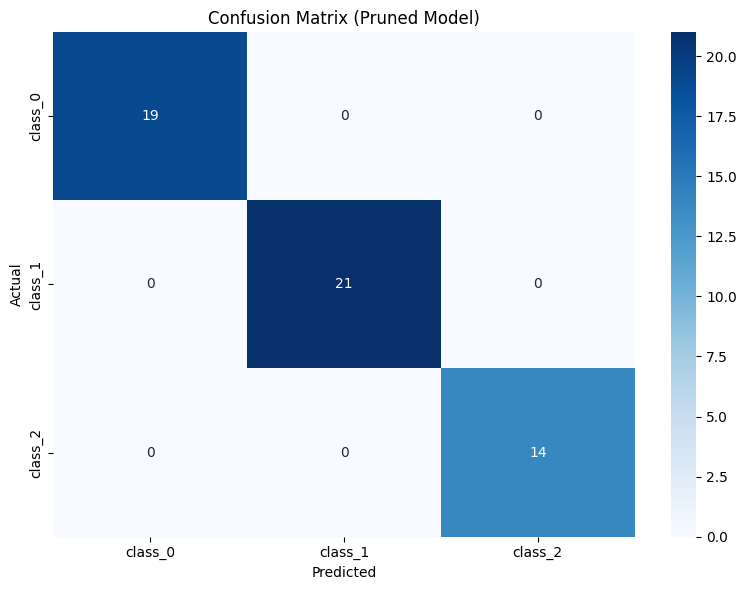

In [20]:
# Step 5: Evaluate using the stripped model
y_true = np.argmax(y_test, axis=1)

# Generate predictions from the stripped model
y_pred_pruned = np.argmax(model_stripped.predict(X_test), axis=1)

# Print classification report
print("Classification Report (Pruned Model):")
print(classification_report(y_true, y_pred_pruned, target_names=wine.target_names))

cm = confusion_matrix(y_true, y_pred_pruned)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=wine.target_names,
            yticklabels=wine.target_names)
plt.title('Confusion Matrix (Pruned Model)')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

## Problem 1 - Part (d)

### Knowledge Distillation

In [21]:
# Step 1: Define the Student model
model_student = Sequential([
    Dense(32, activation='relu', input_shape=(X_train.shape[1],)),
    Dense(16, activation='relu'),
    Dense(num_classes, activation='softmax')
])

model_student.summary()

Model: "sequential_2"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense_6 (Dense)             (None, 32)                448       
                                                                 
 dense_7 (Dense)             (None, 16)                528       
                                                                 
 dense_8 (Dense)             (None, 3)                 51        
                                                                 
Total params: 1027 (4.01 KB)
Trainable params: 1027 (4.01 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


In [22]:
# Step 2: Obtain teacher soft labels from the trained teacher model
teacher_soft_labels = model.predict(X_train)

4/4 [==============================] - 0s 3ms/step


In [23]:
import numpy as np

# Step 3(a): Concatenate hard and soft labels along axis=1
y_train_combined = np.concatenate([y_train, teacher_soft_labels], axis=1)

print("y_train shape:          ", y_train.shape)           # (124, 3)
print("teacher_soft_labels:    ", teacher_soft_labels.shape) # (124, 3)
print("y_train_combined shape: ", y_train_combined.shape)  # (124, 6)

# Step 3(b): Define the custom distillation loss
alpha = 0.5

def distillation_loss(y_true_combined, y_pred):
    # Split combined labels back into hard and soft
    y_true_hard = y_true_combined[:, :3]   # one-hot encoded ground truth
    y_true_soft = y_true_combined[:, 3:]   # teacher soft probabilities

    # Compute hard loss (student vs ground truth)
    hard_loss = tf.keras.losses.categorical_crossentropy(y_true_hard, y_pred)

    # Compute soft loss (student vs teacher soft labels)
    soft_loss = tf.keras.losses.categorical_crossentropy(y_true_soft, y_pred)

    # Combine losses with alpha weighting
    return alpha * hard_loss + (1 - alpha) * soft_loss

y_train shape:           (124, 3)
teacher_soft_labels:     (124, 3)
y_train_combined shape:  (124, 6)


In [24]:
# Step 4: Compile the student model with distillation loss
model_student.compile(optimizer='adam',
                      loss=distillation_loss)

# Train the student model
history_student = model_student.fit(X_train, y_train_combined,
                                    epochs=10,
                                    batch_size=8,
                                    validation_split=0.2)

Epoch 1/10
13/13 [==============================] - 1s 17ms/step - loss: 0.9629 - val_loss: 0.9343
Epoch 2/10
13/13 [==============================] - 0s 5ms/step - loss: 0.8044 - val_loss: 0.7928
Epoch 3/10
13/13 [==============================] - 0s 5ms/step - loss: 0.6884 - val_loss: 0.6870
Epoch 4/10
13/13 [==============================] - 0s 4ms/step - loss: 0.5993 - val_loss: 0.5968
Epoch 5/10
13/13 [==============================] - 0s 5ms/step - loss: 0.5259 - val_loss: 0.5209
Epoch 6/10
13/13 [==============================] - 0s 5ms/step - loss: 0.4592 - val_loss: 0.4503
Epoch 7/10
13/13 [==============================] - 0s 5ms/step - loss: 0.4030 - val_loss: 0.3963
Epoch 8/10
13/13 [==============================] - 0s 5ms/step - loss: 0.3543 - val_loss: 0.3512
Epoch 9/10
13/13 [==============================] - 0s 5ms/step - loss: 0.3140 - val_loss: 0.3152
Epoch 10/10
13/13 [==============================] - 0s 5ms/step - loss: 0.2793 - val_loss: 0.2814


In [25]:
# Step 5: Convert the student model to TFLite
converter = tf.lite.TFLiteConverter.from_keras_model(model_student)
tflite_student_model = converter.convert()

# Save the TFLite model
student_tflite_path = "model_kd.tflite"
with open(student_tflite_path, 'wb') as f:
    f.write(tflite_student_model)

# Print the file size in KB
print(f"Student TFLite model saved as '{student_tflite_path}'")
print(f"File size: {file_size_kb(student_tflite_path):.2f} KB")

INFO:tensorflow:Assets written to: /tmp/tmpyr4r5qp7/assets


INFO:tensorflow:Assets written to: /tmp/tmpyr4r5qp7/assets
2026-05-19 14:15:39.627768: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:378] Ignored output_format.
2026-05-19 14:15:39.627802: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:381] Ignored drop_control_dependency.
2026-05-19 14:15:39.627979: I tensorflow/cc/saved_model/reader.cc:83] Reading SavedModel from: /tmp/tmpyr4r5qp7
2026-05-19 14:15:39.628819: I tensorflow/cc/saved_model/reader.cc:51] Reading meta graph with tags { serve }
2026-05-19 14:15:39.628830: I tensorflow/cc/saved_model/reader.cc:146] Reading SavedModel debug info (if present) from: /tmp/tmpyr4r5qp7
2026-05-19 14:15:39.631378: I tensorflow/cc/saved_model/loader.cc:233] Restoring SavedModel bundle.
2026-05-19 14:15:39.665703: I tensorflow/cc/saved_model/loader.cc:217] Running initialization op on SavedModel bundle at path: /tmp/tmpyr4r5qp7
2026-05-19 14:15:39.675058: I tensorflow/cc/saved_model/loader.cc:316] SavedModel

Student TFLite model saved as 'model_kd.tflite'
File size: 6.10 KB


2/2 [==============================] - 0s 4ms/step
Student Accuracy: 1.0000

Classification Report (Student Model):
              precision    recall  f1-score   support

     class_0       1.00      1.00      1.00        19
     class_1       1.00      1.00      1.00        21
     class_2       1.00      1.00      1.00        14

    accuracy                           1.00        54
   macro avg       1.00      1.00      1.00        54
weighted avg       1.00      1.00      1.00        54



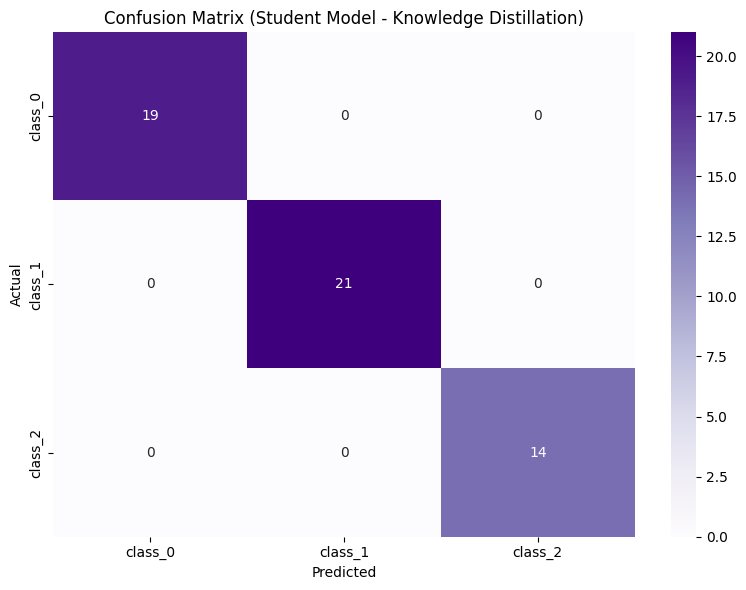

In [26]:
# Step 6: Evaluate the student model on test data

y_true = np.argmax(y_test, axis=1)
y_pred_student = np.argmax(model_student.predict(X_test), axis=1)
print(f"Student Accuracy: {np.mean(y_pred_student == y_true):.4f}")

print("\nClassification Report (Student Model):")
print(classification_report(y_true, y_pred_student, target_names=wine.target_names))

cm = confusion_matrix(y_true, y_pred_student)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Purples',
            xticklabels=wine.target_names,
            yticklabels=wine.target_names)
plt.title('Confusion Matrix (Student Model - Knowledge Distillation)')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

## Problem 1 - Part (e)

### Possibility of Further Model Size Reduction

Can you **further reduce the model size** beyond the smallest model obtained in parts **(b)**, **(c)**, or **(d)**, **without sacrificing significant classification performance**?

Your task is to:

1. **Analyze and compare** the results from previous parts: Which model had the smallest size? Which performed best?

The model that had the smallest size was the studentized version, and the best performer overall was the quantized version. 

2. **Propose a strategy** that combines or enhances techniques learned so far.

A combination of the three techniques would lead to a model that benefits from all of the methodologies for compression. This should be done in the order of studentization to decrease the total model size, followed by pruning, then finally quantizing the whole thing. 

4. **Implement** your proposed solution.

See below

5. **Evaluate** the resulting model using both:
   - TFLite model size (in KB)
   - Classification performance (accuracy and report)

The final result had a size of 3.70 KB. It performed with a minimal discernable decrease in F1 score in comparison to the best performance of the individual techniques. 

6. **Justify your results:**
   - If further size reduction is **not** possible without major loss of accuracy, explain why.
  
Further size reduction without significant accuracy loss is likely not possible as the current implementation already uses the three techniques to their theoretical maxima. This is because the studentization architecture is already minimal, the pruning sparsity is already aggressive, and that we already quantize to 8 bit integers.


### **Note:** If this part includes any code, please include it below. The related discussion should be submitted as part of your PDF that contains answers to all [Dis] questions in this assignment.


In [28]:
# Stage 1: Distillation/Pruning
end_step         = int(len(X_train) / 8 * 20)
pruning_schedule = tfmot.sparsity.keras.PolynomialDecay(
    initial_sparsity=0.50, final_sparsity=0.70,
    begin_step=0, end_step=end_step
)

prune_low_magnitude  = tfmot.sparsity.keras.prune_low_magnitude
model_student_pruned = Sequential([
    prune_low_magnitude(Dense(32, activation='relu', input_shape=(X_train.shape[1],)),
                        pruning_schedule=pruning_schedule),
    prune_low_magnitude(Dense(16, activation='relu'),
                        pruning_schedule=pruning_schedule),
    prune_low_magnitude(Dense(num_classes, activation='softmax'),
                        pruning_schedule=pruning_schedule)
])

model_student_pruned.compile(optimizer='adam', loss=distillation_loss)
model_student_pruned.fit(X_train, y_train_combined,
                         epochs=50, batch_size=8,
                         validation_split=0.2,
                         callbacks=[tfmot.sparsity.keras.UpdatePruningStep()],
                         verbose=1)

model_student_stripped = tfmot.sparsity.keras.strip_pruning(model_student_pruned)
print("Finished pruning")

Epoch 1/50
13/13 [==============================] - 1s 19ms/step - loss: 1.0231 - val_loss: 1.0110
Epoch 2/50
13/13 [==============================] - 0s 5ms/step - loss: 0.8833 - val_loss: 0.8967
Epoch 3/50
13/13 [==============================] - 0s 5ms/step - loss: 0.7698 - val_loss: 0.7967
Epoch 4/50
13/13 [==============================] - 0s 5ms/step - loss: 0.6608 - val_loss: 0.7062
Epoch 5/50
13/13 [==============================] - 0s 4ms/step - loss: 0.5653 - val_loss: 0.6259
Epoch 6/50
13/13 [==============================] - 0s 5ms/step - loss: 0.4772 - val_loss: 0.5534
Epoch 7/50
13/13 [==============================] - 0s 6ms/step - loss: 0.3998 - val_loss: 0.4982
Epoch 8/50
13/13 [==============================] - 0s 5ms/step - loss: 0.4670 - val_loss: 0.7243
Epoch 9/50
13/13 [==============================] - 0s 5ms/step - loss: 0.6632 - val_loss: 0.6485
Epoch 10/50
13/13 [==============================] - 0s 5ms/step - loss: 0.5752 - val_loss: 0.5783
Epoch 11/50
13/13 

In [29]:
quantize_and_evaluate(model_student_stripped, X_test, y_test,
                      quant_type='int8',
                      filename='model_kd_pruned_int8.tflite')

print("Int8 quantization completed")

INFO:tensorflow:Assets written to: /tmp/tmpi8h5y_2x/assets


INFO:tensorflow:Assets written to: /tmp/tmpi8h5y_2x/assets



INT8 TFLite model size: 3.70 KB

Classification Report (INT8):
              precision    recall  f1-score   support

     class_0       1.00      0.95      0.97        19
     class_1       0.95      1.00      0.98        21
     class_2       1.00      1.00      1.00        14

    accuracy                           0.98        54
   macro avg       0.98      0.98      0.98        54
weighted avg       0.98      0.98      0.98        54

Confusion Matrix (INT8):
[[18  1  0]
 [ 0 21  0]
 [ 0  0 14]]
Int8 quantization completed


/home/Brayden/ai/projects/tinyml-arduino/lib/python3.11/site-packages/tensorflow/lite/python/convert.py:947: UserWarning: Statistics for quantized inputs were expected, but not specified; continuing anyway.
  warnings.warn(
2026-05-19 14:15:45.152849: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:378] Ignored output_format.
2026-05-19 14:15:45.152882: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:381] Ignored drop_control_dependency.
2026-05-19 14:15:45.153074: I tensorflow/cc/saved_model/reader.cc:83] Reading SavedModel from: /tmp/tmpi8h5y_2x
2026-05-19 14:15:45.153644: I tensorflow/cc/saved_model/reader.cc:51] Reading meta graph with tags { serve }
2026-05-19 14:15:45.153654: I tensorflow/cc/saved_model/reader.cc:146] Reading SavedModel debug info (if present) from: /tmp/tmpi8h5y_2x
2026-05-19 14:15:45.155052: I tensorflow/cc/saved_model/loader.cc:233] Restoring SavedModel bundle.
2026-05-19 14:15:45.170866: I tensorflow/cc/saved_model/load

# Problem 2: Exploring Edge Impulse (20 points)


### Note

Problem 2 consists entirely of discussion questions. Submit your responses in the same PDF file that contains answers to the other **[Dis]** questions in this assignment.

Before submission, make sure this notebook runs with the **Python (tinyml-arduino)** kernel and that all requested outputs are visible. Host this notebook and your discussion PDF in your public GitHub repository, then submit the repository link through Canvas.
